In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# for linear probe
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA

In [2]:
# --- Configuration ---
SEQ_LENGTH = 400
HMM_CONCEPTS = ['A', 'B', 'C']  # 3 tokens for Mess3 HMM


In [3]:
# --- Create HMM and generate sequence with hidden states ---
from src.hmm.hmm import Mess3HMM

hmm = Mess3HMM()
hmm.create_hmm(x=0.05, alpha=0.85)

# Create emission matrix: emission_probs[state, token] = P(emit token | in state)
# T_3d_matrix has shape (vocab_size, n_states, n_states)
# T_3d_matrix[token, from_state, to_state] = P(emit token, go to to_state | in from_state)
# Sum over to_states to get emission probs
emission_matrix = hmm.T_3d_matrix.sum(dim=2).T  # Shape: (n_states, vocab_size) = (3, 3)
emission_matrix = emission_matrix / emission_matrix.sum(dim=1, keepdim=True)  # Normalize

print("Emission matrix (rows=states, cols=tokens A,B,C):")
print(emission_matrix)
print(f"\nRow sums (should be 1): {emission_matrix.sum(dim=1)}")


Emission matrix (rows=states, cols=tokens A,B,C):
tensor([[0.7725, 0.1137, 0.1137],
        [0.1138, 0.7725, 0.1138],
        [0.1137, 0.1137, 0.7725]], device='cuda:0')

Row sums (should be 1): tensor([1., 1., 1.], device='cuda:0')


In [4]:
# Generate sequence with hidden states
tokens, tokens_y, hidden_states = hmm.generate_dataset(1, SEQ_LENGTH, return_states=True)
tokens = tokens.squeeze(0)  # (1, seq_length) -> (seq_length,)
hidden_states = hidden_states.squeeze(0)

# Convert to concept strings
walk_concepts = [HMM_CONCEPTS[t.item()] for t in tokens]

print(f"Sequence length: {len(tokens)}")
print(f"First 20 tokens: {walk_concepts[:20]}")
print(f"First 20 states: {hidden_states[:20].tolist()}")
print(f"\nToken distribution: A={walk_concepts.count('A')}, B={walk_concepts.count('B')}, C={walk_concepts.count('C')}")


/home/chiragr2/computational-mechanics/geometric_interpretability_LLMs/src/hmm/hmm.py:254: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4413.)
  test = self.T_3d_matrix[:, :, state_idx].T.unsqueeze(0).reshape(num_sequences, -1)


Sequence length: 400
First 20 tokens: ['A', 'A', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'C']
First 20 states: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Token distribution: A=150, B=117, C=133


In [5]:
walk_concepts[:20] == ['A', 'A', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'C']

True

In [6]:
# --- Load LLM ---
from src.models.llm_interface import LlamaInterface

llm = LlamaInterface("llama-3.1-8b")


Loading llama-3.1-8b on cuda...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded successfully! Layers: 32


In [7]:
# --- Helper function ---
def get_concept_token_ids(llm, concepts):
    """Get the token IDs for each concept (with space prefix)."""
    concept_to_id = {}
    for concept in concepts:
        spaced = f" {concept}"
        ids, tokens = llm.tokenize(spaced)
        concept_to_id[concept] = ids[-1]
    return concept_to_id


In [8]:
# print(f"Logits shape: {outputs.logits.shape}")

# # If you want to check past_key_values shapes
# if outputs.past_key_values is not None:
#     # For DynamicCache, you can check the key/value shapes per layer
#     for i, layer in enumerate(outputs.past_key_values):
#         print(f"Layer {i} key shape: {layer[0].shape}, value shape: {layer[1].shape}")

## Run Forward pass

In [9]:
# concept_to_id = {'A': 362, 'B': 426, 'C': 356}
# # Or as a tensor
# concept_token_ids = torch.tensor([concept_to_id[c] for c in walk_concepts])
# concept_token_ids[:10]
walk_concepts[:10]

['A', 'A', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A']

In [11]:
# inputs['input_ids'][0,:10]

In [12]:
walk_concepts[0] + " " + " ".join(walk_concepts[1:10])

'A A A B A A A A A A'

In [13]:
# --- Single forward pass to get all logits ---
print("Running single forward pass...")

# Get concept token IDs for A, B, C
concept_to_id = get_concept_token_ids(llm, HMM_CONCEPTS)
concept_ids = torch.tensor([concept_to_id[c] for c in HMM_CONCEPTS])

print(f"Concept token IDs: {concept_to_id}")

# Tokenize the sequence
text = text = walk_concepts[0] + " " + " ".join(walk_concepts[1:]) #" ".join(walk_concepts) # no space at the start
inputs = llm.tokenizer(text, return_tensors="pt").to(llm.device)
input_ids = inputs.input_ids[0]

print(f"Input sequence length (tokens): {len(input_ids)}")

# Forward pass
with torch.no_grad():
    outputs = llm.model(**inputs, output_hidden_states=True, return_dict=True)
    logits = outputs.logits[0]  # Shape: (seq_len, vocab_size)

print(f"Logits shape: {logits.shape}")

# Extract logits for A, B, C and convert to probabilities
concept_ids_device = concept_ids.to(logits.device)
concept_logits = logits[:, concept_ids_device]  # Shape: (seq_len, 3)
llm_probs = F.softmax(concept_logits, dim=1)  # Shape: (seq_len, 3)

print(f"LLM probs shape: {llm_probs.shape}")


Running single forward pass...
Concept token IDs: {'A': 362, 'B': 426, 'C': 356}
Input sequence length (tokens): 401
Logits shape: torch.Size([401, 128256])
LLM probs shape: torch.Size([401, 3])


In [25]:
# inputs['input_ids'][0,:10]

In [14]:
concept_logits.shape

torch.Size([401, 3])

In [15]:
outputs.hidden_states[0].shape

torch.Size([1, 401, 4096])

## Extract activations 

In [16]:
# outputs.hidden_states is a tuple of (num_layers+1) tensors
# Layer 0 = embeddings, Layers 1-32 = transformer layers
hidden_states_all = outputs.hidden_states
print(f"Number of hidden state layers: {len(hidden_states_all)}")
print(f"Each layer shape: {hidden_states_all[0].shape}")

# Extract activations from last layer and layer 26
layer_indices = {'layer_26': 26, 'last_layer': -1}
activations_by_layer = {}

for name, layer_idx in layer_indices.items():
    activations = hidden_states_all[layer_idx].squeeze(0)  # Shape: (seq_len, hidden_dim)
    activations_by_layer[name] = activations.cpu().float().numpy()
    print(f"{name} activations shape: {activations_by_layer[name].shape}")

Number of hidden state layers: 33
Each layer shape: torch.Size([1, 401, 4096])
layer_26 activations shape: (401, 4096)
last_layer activations shape: (401, 4096)


In [17]:
HMM_CONCEPTS

['A', 'B', 'C']

In [18]:
hidden_states.shape

torch.Size([400])

# Compare emission probs with LLM probs

In [1]:
# --- Compute emission probability match at each position ---
# Compare LLM's predicted distribution with HMM's emission distribution given the hidden state

token_id_to_concept_idx = {concept_to_id[c]: i for i, c in enumerate(HMM_CONCEPTS)}
actual_token_ids = input_ids[1:]  # Tokens we're predicting (shifted by 1)

# Move emission matrix to same device as llm_probs
emission_matrix_device = emission_matrix.to(llm_probs.device)

emission_prob_matches = []  # Dot product of LLM probs with HMM emission probs
positions = []
state_ids = []

for i, token_id in enumerate(actual_token_ids.tolist()):
    if token_id in token_id_to_concept_idx:
        # Get hidden state at position i (the state BEFORE emitting token i+1)
        state_idx = hidden_states[i].item()
        
        # Get HMM emission distribution for this state
        hmm_emission_probs = emission_matrix_device[state_idx]  # Shape: (3,)
        
        # Get LLM's predicted distribution at position i (predicting token i+1)
        llm_pred_probs = llm_probs[i]  # Shape: (3,)
        
        # Compute match: dot product (how much LLM agrees with HMM emission dist)
        # This equals sum of LLM probs weighted by HMM emission probs
        match = (llm_pred_probs * hmm_emission_probs).sum().item()
        
        emission_prob_matches.append(match)
        positions.append(i)
        state_ids.append(state_idx)

# Convert to arrays
positions = np.array(positions)
emission_prob_matches = np.array(emission_prob_matches)
state_ids = np.array(state_ids)

# Compute running average
running_avg = np.cumsum(emission_prob_matches) / np.arange(1, len(emission_prob_matches) + 1)

print(f"Valid positions: {len(positions)}")
print(f"Mean emission match: {np.mean(emission_prob_matches):.4f}")

NameError: name 'HMM_CONCEPTS' is not defined

## KL divergence

In [ ]:
# --- Compute KL divergence between HMM emission dist and LLM predicted dist ---

token_id_to_concept_idx = {concept_to_id[c]: i for i, c in enumerate(HMM_CONCEPTS)}
actual_token_ids = input_ids[1:]

emission_matrix_device = emission_matrix.to(llm_probs.device)

kl_divergences = []
positions = []
state_ids = []

eps = 1e-10

for i, token_id in enumerate(actual_token_ids.tolist()):
    if token_id in token_id_to_concept_idx:
        state_idx = hidden_states[i].item()
        hmm_emission_probs = emission_matrix_device[state_idx]  # Shape: (3,)
        llm_pred_probs = llm_probs[i]  # Shape: (3,)

        # D_KL(HMM || LLM): how well LLM approximates the HMM emission dist
        kl = (hmm_emission_probs * torch.log(hmm_emission_probs / (llm_pred_probs + eps))).sum().item()

        kl_divergences.append(kl)
        positions.append(i)
        state_ids.append(state_idx)

positions = np.array(positions)
kl_divergences = np.array(kl_divergences)
state_ids = np.array(state_ids)

running_avg = np.cumsum(kl_divergences) / np.arange(1, len(kl_divergences) + 1)

print(f"Valid positions: {len(positions)}")
print(f"Mean KL divergence (HMM || LLM): {np.mean(kl_divergences):.4f}")

In [20]:
# --- Show sample positions ---
print("--- Sample positions ---")
print("Emission matrix per state:")
for s in range(3):
    print(f"  State {s}: A={emission_matrix[s,0]:.3f}, B={emission_matrix[s,1]:.3f}, C={emission_matrix[s,2]:.3f}")

print("\n--- Sample predictions ---")
for target_pos in [5, 100, 500, 1000, 2000, 3000]:
    if target_pos in positions:
        idx = np.where(positions == target_pos)[0][0]
        state = state_ids[idx]
        match = emission_prob_matches[idx]
        hmm_probs = emission_matrix[state].cpu().numpy()
        llm_pred = llm_probs[target_pos].cpu().numpy()
        print(f"Position {target_pos}: State={state}, Match={match:.4f}")
        print(f"  HMM emission: A={hmm_probs[0]:.3f}, B={hmm_probs[1]:.3f}, C={hmm_probs[2]:.3f}")
        print(f"  LLM predicts: A={llm_pred[0]:.3f}, B={llm_pred[1]:.3f}, C={llm_pred[2]:.3f}")

--- Sample positions ---
Emission matrix per state:
  State 0: A=0.773, B=0.114, C=0.114
  State 1: A=0.114, B=0.773, C=0.114
  State 2: A=0.114, B=0.114, C=0.773

--- Sample predictions ---
Position 5: State=0, Match=0.4322
  HMM emission: A=0.773, B=0.114, C=0.114
  LLM predicts: A=0.483, B=0.407, C=0.110
Position 100: State=0, Match=0.6361
  HMM emission: A=0.773, B=0.114, C=0.114
  LLM predicts: A=0.793, B=0.095, C=0.112


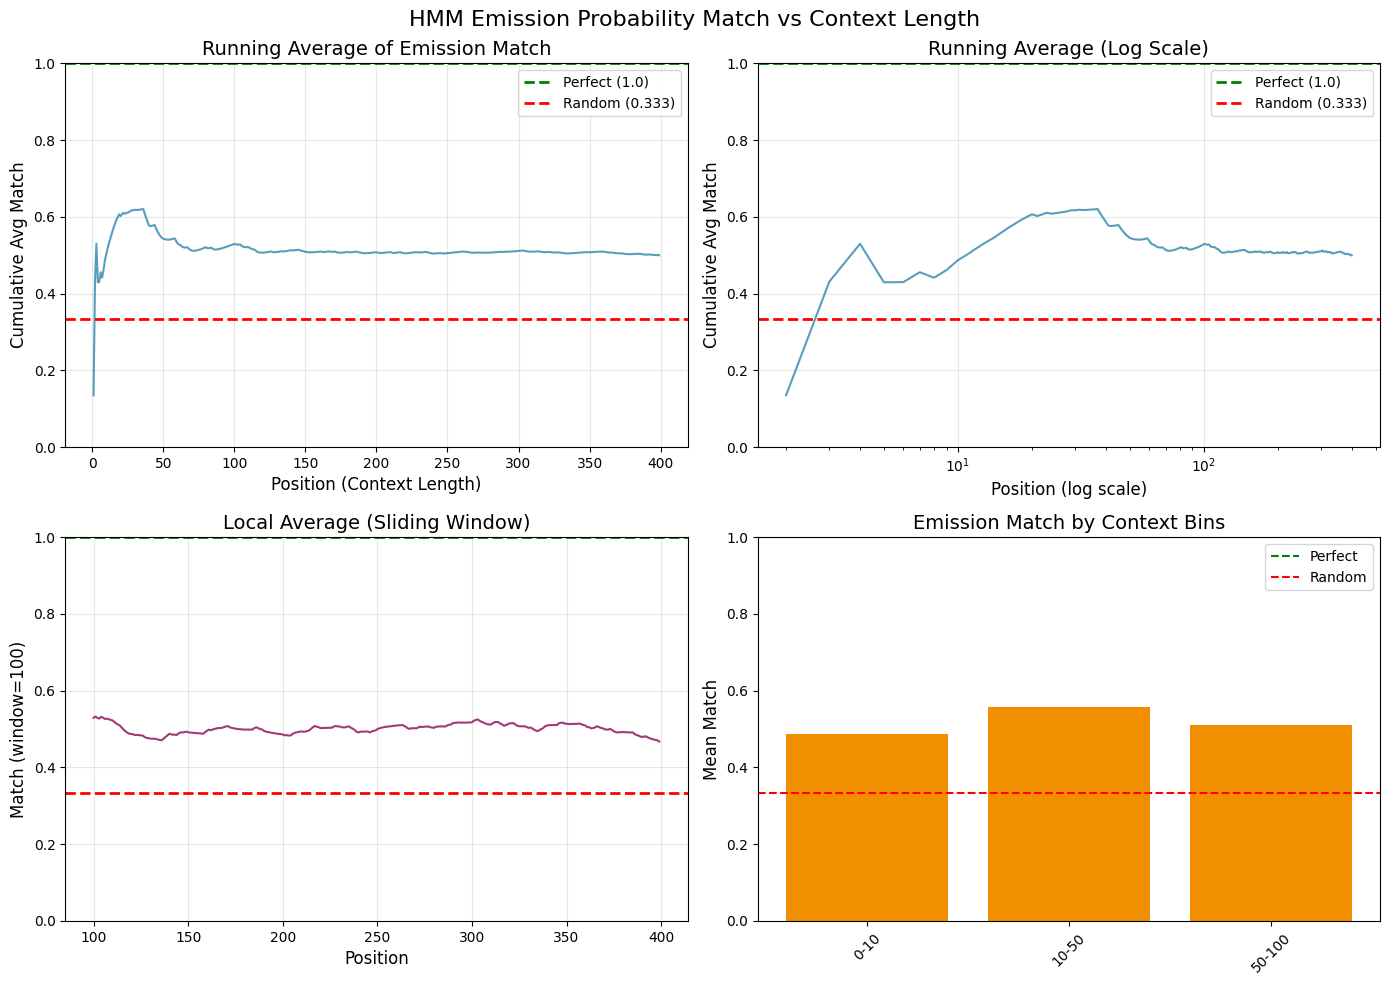


Final average emission match: 0.4998
Random baseline (1/3): 0.3333


In [21]:
# --- Plot emission match vs context length ---

# Random baseline: uniform LLM probs would give 1/3 match with any emission dist
random_baseline = 1/3

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HMM Emission Probability Match vs Context Length', fontsize=16)

# Plot 1: Running average
ax1 = axes[0, 0]
ax1.plot(positions, running_avg, linewidth=1.5, color='#2E86AB', alpha=0.8)
ax1.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
ax1.axhline(y=random_baseline, color='red', linestyle='--', linewidth=2, label=f'Random ({random_baseline:.3f})')
ax1.set_xlabel('Position (Context Length)', fontsize=12)
ax1.set_ylabel('Cumulative Avg Match', fontsize=12)
ax1.set_title('Running Average of Emission Match', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Plot 2: Log scale x-axis
ax2 = axes[0, 1]
ax2.semilogx(positions + 1, running_avg, linewidth=1.5, color='#2E86AB', alpha=0.8)
ax2.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
ax2.axhline(y=random_baseline, color='red', linestyle='--', linewidth=2, label=f'Random ({random_baseline:.3f})')
ax2.set_xlabel('Position (log scale)', fontsize=12)
ax2.set_ylabel('Cumulative Avg Match', fontsize=12)
ax2.set_title('Running Average (Log Scale)', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

# Plot 3: Sliding window average
window = 100
if len(emission_prob_matches) > window:
    slide_avg = np.convolve(emission_prob_matches, np.ones(window)/window, mode='valid')
    ax3 = axes[1, 0]
    ax3.plot(positions[window-1:], slide_avg, linewidth=1.5, color='#A23B72')
    ax3.axhline(y=1.0, color='green', linestyle='--', linewidth=2)
    ax3.axhline(y=random_baseline, color='red', linestyle='--', linewidth=2)
    ax3.set_xlabel('Position', fontsize=12)
    ax3.set_ylabel(f'Match (window={window})', fontsize=12)
    ax3.set_title('Local Average (Sliding Window)', fontsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1)

# Plot 4: Binned average
bins = [0, 10, 50, 100, 500, 1000, 5000]
bins = [b for b in bins if b <= max(positions)]
avgs, labels = [], []
for i in range(len(bins)-1):
    m = (positions >= bins[i]) & (positions < bins[i+1])
    if np.any(m):
        avgs.append(np.mean(emission_prob_matches[m]))
        labels.append(f'{bins[i]}-{bins[i+1]}')
ax4 = axes[1, 1]
ax4.bar(range(len(avgs)), avgs, color='#F18F01')
ax4.axhline(y=1.0, color='green', linestyle='--', label='Perfect')
ax4.axhline(y=random_baseline, color='red', linestyle='--', label='Random')
ax4.set_xticks(range(len(labels)))
ax4.set_xticklabels(labels, rotation=45)
ax4.set_ylabel('Mean Match', fontsize=12)
ax4.set_title('Emission Match by Context Bins', fontsize=14)
ax4.set_ylim(0, 1)
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal average emission match: {running_avg[-1]:.4f}")
print(f"Random baseline (1/3): {random_baseline:.4f}")


## Accuracy over the last sliding window

In [22]:
llm_probs.shape

torch.Size([401, 3])

In [26]:

# # Filter out invalid positions (where token wasn't A, B, or C)
# valid_mask = tokens_y[0, 2:] >= 0
# valid_correct = correct[valid_mask].cpu().numpy()
# valid_positions = np.where(valid_mask.cpu().numpy())[0]

# # Compute sliding window accuracy (past 100 values including current)
# sliding_accuracy = np.zeros(len(valid_correct))
# for i in range(len(valid_correct)):
#     start_idx = max(0, i - window + 1)
#     sliding_accuracy[i] = np.mean(valid_correct[start_idx:i+1])

# # Overall accuracy
# overall_accuracy = np.mean(valid_correct)

In [29]:
# Sliding window accuracy
window = 20

###### Important: We remove the first 2 as well as it was a BOS and space token

# Get LLM predictions: argmax of probabilities at position i predicts token at i+1
llm_predictions = torch.argmax(llm_probs[2:-1], dim=1)  # Shape: (seq_len-1,)
correct = (llm_predictions == tokens_y[0, 2:]).float().cpu().numpy()

# Compute sliding window accuracy (past 100 values including current)
sliding_accuracy = np.zeros(len(correct))
for i in range(len(correct)):
    start_idx = max(0, i - window + 1)
    sliding_accuracy[i] = np.mean(correct[start_idx:i+1])

# Overall accuracy
overall_accuracy = np.mean(correct)

print(f"Overall next-token accuracy: {overall_accuracy:.4f}")
print(f"Sliding window accuracy (window={window}):")
print(f"  First 100 positions: {sliding_accuracy[99]:.4f}" if len(sliding_accuracy) > 99 else "  Not enough data")
print(f"  At position 500: {sliding_accuracy[499]:.4f}" if len(sliding_accuracy) > 499 else "  Not enough data")
print(f"  At position 1000: {sliding_accuracy[999]:.4f}" if len(sliding_accuracy) > 999 else "  Not enough data")
print(f"  At position 2000: {sliding_accuracy[1999]:.4f}" if len(sliding_accuracy) > 1999 else "  Not enough data")
print(f"  Final position: {sliding_accuracy[-1]:.4f}")

Overall next-token accuracy: 0.6784
Sliding window accuracy (window=20):
  First 100 positions: 0.8000
  Not enough data
  Not enough data
  Not enough data
  Final position: 0.7000


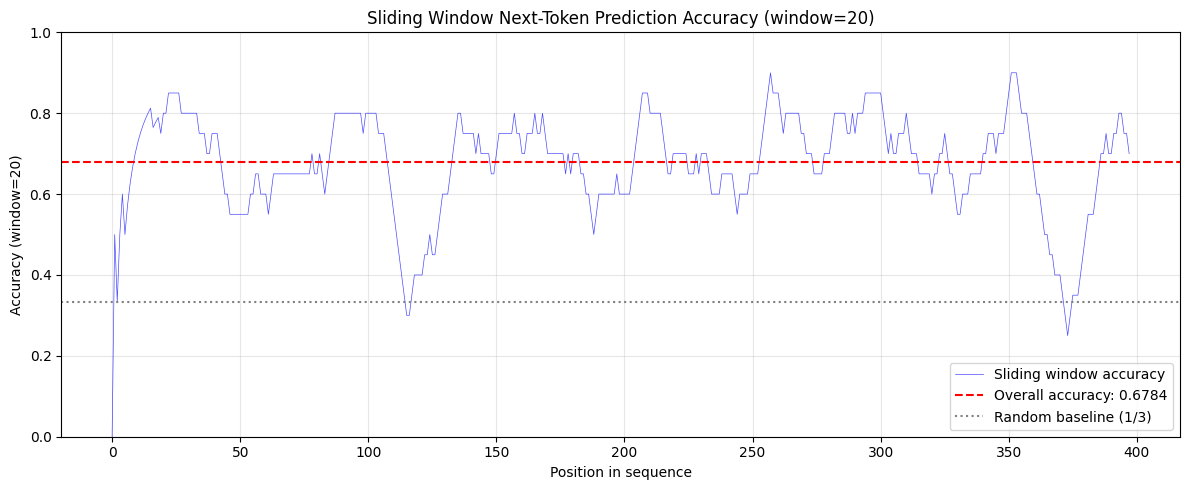

In [30]:
# --- Plot sliding window accuracy vs position ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(len(sliding_accuracy)), sliding_accuracy, 'b-', alpha=0.7, linewidth=0.5, label='Sliding window accuracy')
ax.axhline(y=overall_accuracy, color='r', linestyle='--', label=f'Overall accuracy: {overall_accuracy:.4f}')
ax.axhline(y=1/3, color='gray', linestyle=':', label='Random baseline (1/3)')

ax.set_xlabel('Position in sequence')
ax.set_ylabel(f'Accuracy (window={window})')
ax.set_title(f'Sliding Window Next-Token Prediction Accuracy (window={window})')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Linear Probe

In [31]:
# --- Compute Belief States for Training Data ---
# Belief state = probability distribution over hidden states given observations so far

# Convert tokens back to indices for belief state computation
token_indices = torch.tensor([HMM_CONCEPTS.index(c) for c in walk_concepts], device=hmm.T_3d_matrix.device)
token_indices = token_indices.unsqueeze(0)  # Shape: (1, seq_len)

print(f"Token indices shape: {token_indices.shape}")

# Compute belief states for the sequence
belief_states = hmm.compute_belief_state(token_indices)  # Shape: (1, seq_len+1, n_states)
belief_states = belief_states.squeeze(0).cpu().numpy()  # Shape: (seq_len+1, 3)

print(f"Belief states shape: {belief_states.shape}")
print(f"Sample belief state at position 100: {belief_states[100]}")
print(f"Belief states sum to 1? {np.allclose(belief_states.sum(axis=1), 1)}")

Token indices shape: torch.Size([1, 400])
Belief states shape: (401, 3)
Sample belief state at position 100: [0.8909151  0.05454248 0.05454248]
Belief states sum to 1? True


In [32]:
# --- Fit Linear Probes to Predict Belief States ---
# Linear probe: activations @ W + b = predicted_belief_state

def fit_linear_probe(activations, targets, test_size=0.2, alpha=1.0):
    """
    Fit a linear probe (Ridge regression) to predict targets from activations.
    
    Args:
        activations: (n_samples, hidden_dim) activation vectors
        targets: (n_samples, n_outputs) target values (e.g., belief states)
        test_size: fraction of data to use for testing
        alpha: Ridge regularization parameter
        
    Returns:
        dict with model, predictions, and metrics
    """
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        activations, targets, test_size=test_size, random_state=42
    )
    
    # Fit Ridge regression
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metrics
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    
    return {
        'model': model,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'mse_train': mse_train,
        'mse_test': mse_test,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred_test': y_pred_test
    }

# Align activations with belief states
# Activation at position i predicts the next token, so use belief state at position i
# (belief state after seeing tokens 0..i-1, predicting token i)
# Note: We need to handle the alignment carefully

# Get the number of tokens in the input (after tokenization)
n_tokens = activations_by_layer['last_layer'].shape[0]
print(f"Number of tokens from LLM: {n_tokens}")
print(f"Number of belief states: {belief_states.shape[0]}")

# Find valid positions (where we have concept tokens, not special tokens)
valid_positions = []
for i, tok_id in enumerate(input_ids[:-1].tolist()):
    if tok_id in token_id_to_concept_idx:
        valid_positions.append(i)

valid_positions = np.array(valid_positions)
print(f"Number of valid positions: {len(valid_positions)}")

# For the linear probe, use activations at valid positions
# The belief state at position i represents P(hidden_state | tokens_0:i)
# So activation at position i should predict belief_states[i+1] (after seeing token i)
belief_targets = belief_states[1:len(input_ids)]  # Shift by 1
print(f"Belief targets shape: {belief_targets.shape}")

Number of tokens from LLM: 401
Number of belief states: 401
Number of valid positions: 398
Belief targets shape: (400, 3)


In [33]:
# --- Fit and Evaluate Linear Probes for Each Layer ---

results = {}

for layer_name, activations in activations_by_layer.items():
    print(f"\n{'='*50}")
    print(f"Fitting linear probe for {layer_name}")
    print(f"{'='*50}")
    
    # Use activations at valid positions only
    X = activations[valid_positions]
    y = belief_targets[valid_positions]
    
    print(f"Training data shape: X={X.shape}, y={y.shape}")
    
    # Fit the probe
    result = fit_linear_probe(X, y, test_size=0.2, alpha=1.0)
    results[layer_name] = result
    
    print(f"R² Score (train): {result['r2_train']:.4f}")
    print(f"R² Score (test):  {result['r2_test']:.4f}")
    print(f"MSE (train): {result['mse_train']:.6f}")
    print(f"MSE (test):  {result['mse_test']:.6f}")

# Summary comparison
print(f"\n{'='*60}")
print("SUMMARY: Linear Probe Performance")
print(f"{'='*60}")
print(f"{'Layer':<15} {'R² (train)':<12} {'R² (test)':<12} {'MSE (test)':<12}")
print("-" * 60)
for layer_name, result in results.items():
    print(f"{layer_name:<15} {result['r2_train']:<12.4f} {result['r2_test']:<12.4f} {result['mse_test']:<12.6f}")


Fitting linear probe for layer_26
Training data shape: X=(398, 4096), y=(398, 3)
R² Score (train): 0.9589
R² Score (test):  0.6599
MSE (train): 0.004968
MSE (test):  0.043543

Fitting linear probe for last_layer
Training data shape: X=(398, 4096), y=(398, 3)
R² Score (train): 0.9914
R² Score (test):  0.2605
MSE (train): 0.001043
MSE (test):  0.091034

SUMMARY: Linear Probe Performance
Layer           R² (train)   R² (test)    MSE (test)  
------------------------------------------------------------
layer_26        0.9589       0.6599       0.043543    
last_layer      0.9914       0.2605       0.091034    


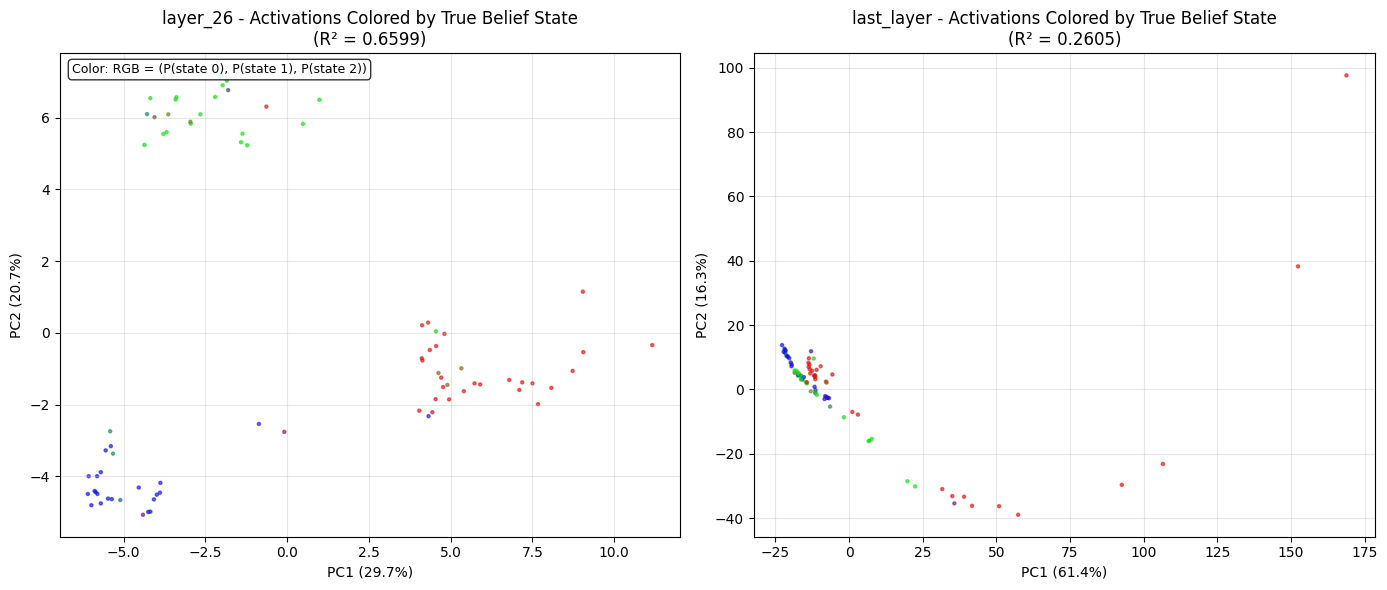

Figure saved to: linear_probe_belief_states.png


In [34]:
# --- Visualize Activations Colored by Belief States ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (layer_name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    # Get activations and belief states for test set
    X_test = result['X_test']
    y_test = result['y_test']
    y_pred = result['y_pred_test']
    
    # Reduce to 2D with PCA
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_test)
    
    # Use belief states as RGB colors (3 states = RGB)
    # Clip to [0, 1] range for valid colors
    colors = np.clip(y_test, 0, 1)
    
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=5, alpha=0.6)
    ax.set_title(f'{layer_name} - Activations Colored by True Belief State\n(R² = {result["r2_test"]:.4f})')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.grid(True, alpha=0.3)

# Add explanation for colors
axes[0].text(0.02, 0.98, 'Color: RGB = (P(state 0), P(state 1), P(state 2))', 
             transform=axes[0].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
plt.tight_layout()
plt.savefig('linear_probe_belief_states.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved to: linear_probe_belief_states.png")

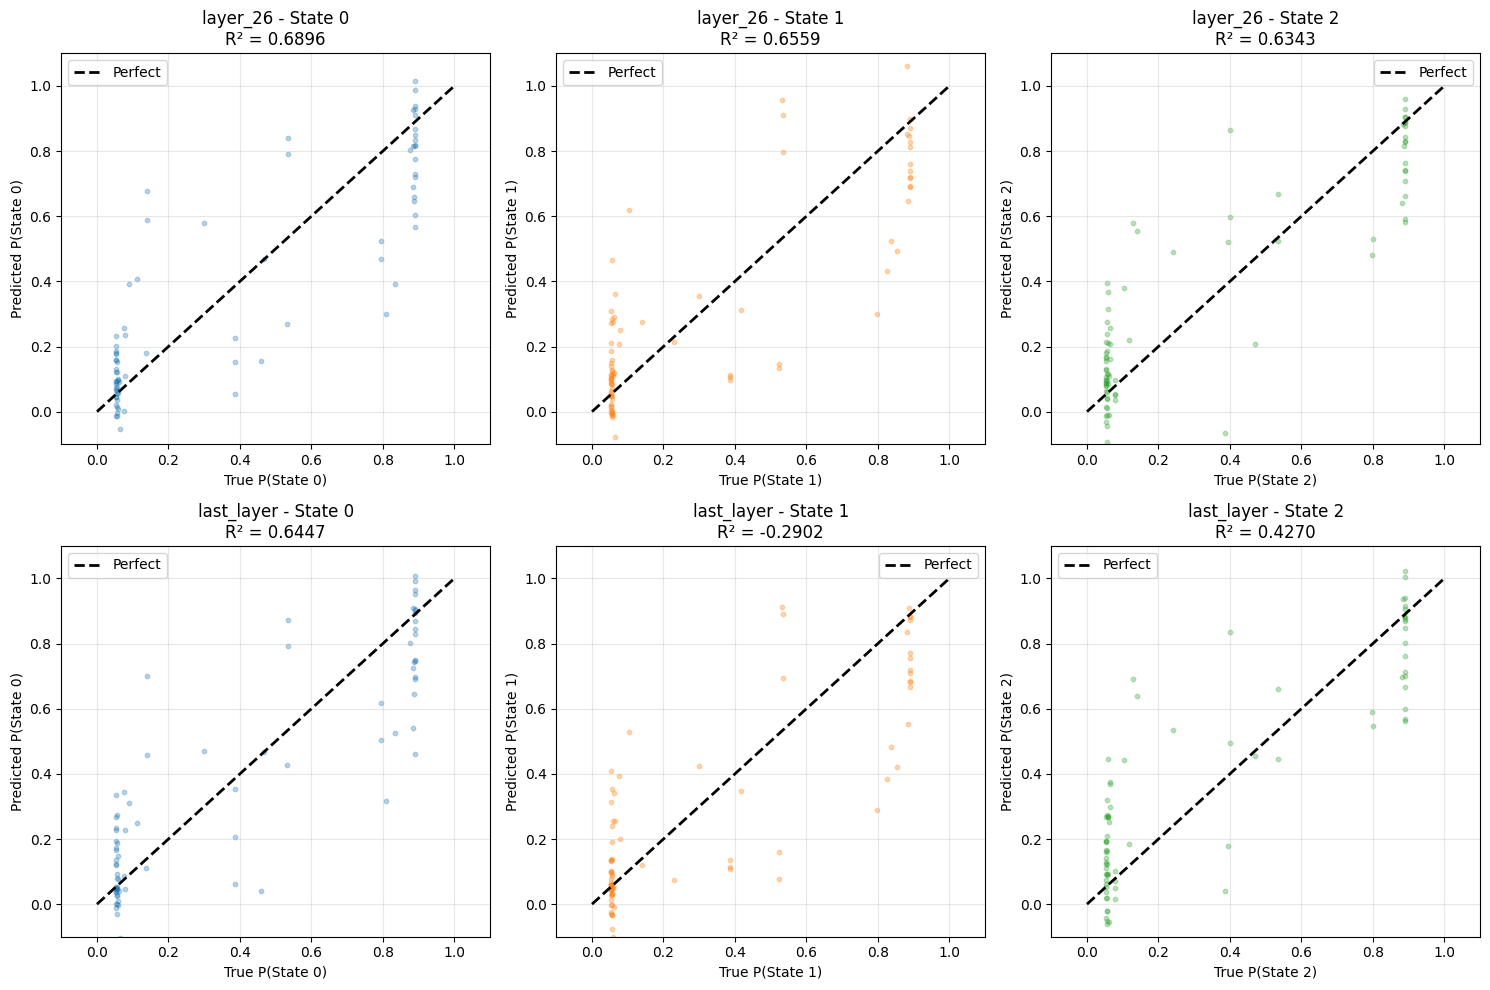

Figure saved to: linear_probe_scatter.png


In [35]:
# --- Compare Predicted vs True Belief States ---

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (layer_name, result) in enumerate(results.items()):
    y_test = result['y_test']
    y_pred = result['y_pred_test']
    
    # Plot each state component
    for state_idx in range(3):
        ax = axes[row, state_idx]
        
        ax.scatter(y_test[:, state_idx], y_pred[:, state_idx], 
                  alpha=0.3, s=10, c=f'C{state_idx}')
        
        # Perfect prediction line
        ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
        
        # Compute per-state R²
        ss_res = np.sum((y_test[:, state_idx] - y_pred[:, state_idx])**2)
        ss_tot = np.sum((y_test[:, state_idx] - y_test[:, state_idx].mean())**2)
        r2_state = 1 - ss_res / ss_tot
        
        ax.set_xlabel(f'True P(State {state_idx})')
        ax.set_ylabel(f'Predicted P(State {state_idx})')
        ax.set_title(f'{layer_name} - State {state_idx}\nR² = {r2_state:.4f}')
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, 1.1)
        ax.grid(True, alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.savefig('linear_probe_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved to: linear_probe_scatter.png")

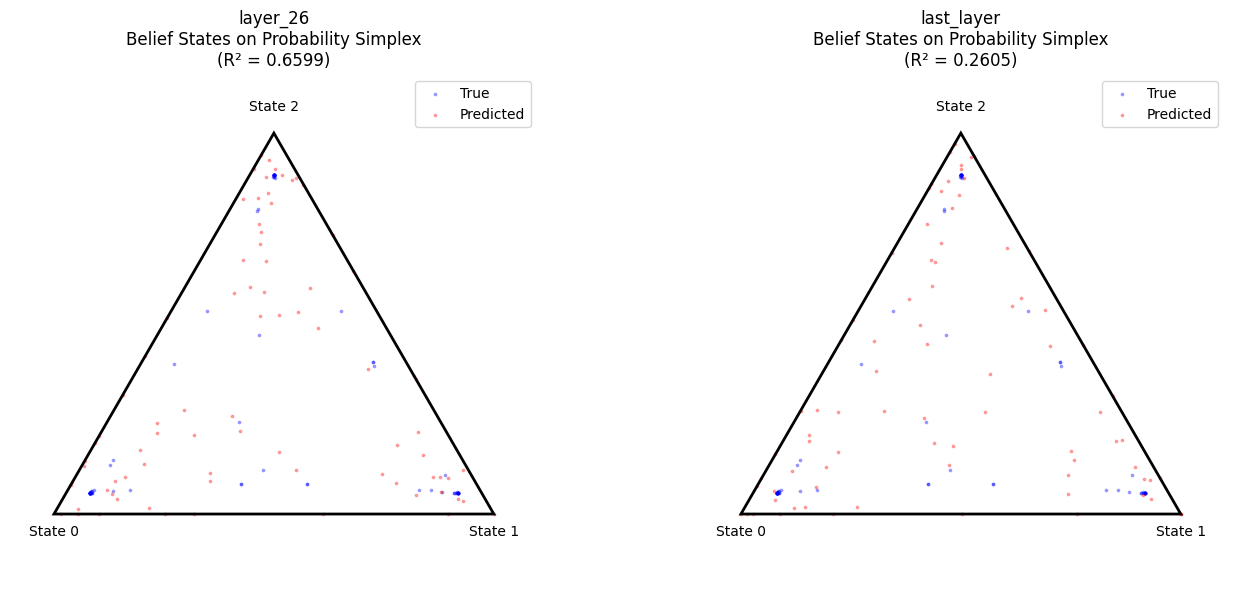

Figure saved to: linear_probe_simplex.png


In [36]:
# --- Visualize Belief States on Simplex ---
# The belief states form a probability simplex (3 states = 2D triangle)

def simplex_to_cartesian(belief_states):
    """Convert belief states to 2D Cartesian coordinates on equilateral triangle."""
    # Vertices of equilateral triangle
    v0 = np.array([0, 0])           # State 0
    v1 = np.array([1, 0])           # State 1
    v2 = np.array([0.5, np.sqrt(3)/2])  # State 2
    
    # Barycentric to Cartesian
    x = belief_states[:, 0] * v0[0] + belief_states[:, 1] * v1[0] + belief_states[:, 2] * v2[0]
    y = belief_states[:, 0] * v0[1] + belief_states[:, 1] * v1[1] + belief_states[:, 2] * v2[1]
    
    return np.column_stack([x, y])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (layer_name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    y_test = result['y_test']
    y_pred = result['y_pred_test']
    
    # Convert to simplex coordinates
    true_coords = simplex_to_cartesian(y_test)
    pred_coords = simplex_to_cartesian(np.clip(y_pred, 0, 1))  # Clip predictions to valid range
    
    # Normalize predictions to sum to 1
    y_pred_normalized = np.clip(y_pred, 0, 1)
    y_pred_normalized = y_pred_normalized / y_pred_normalized.sum(axis=1, keepdims=True)
    pred_coords_norm = simplex_to_cartesian(y_pred_normalized)
    
    # Plot true belief states
    ax.scatter(true_coords[:, 0], true_coords[:, 1], c='blue', s=3, alpha=0.3, label='True')
    ax.scatter(pred_coords_norm[:, 0], pred_coords_norm[:, 1], c='red', s=3, alpha=0.3, label='Predicted')
    
    # Draw simplex triangle
    triangle = plt.Polygon([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]], 
                           fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(triangle)
    
    # Label vertices
    ax.text(0, -0.05, 'State 0', ha='center', fontsize=10)
    ax.text(1, -0.05, 'State 1', ha='center', fontsize=10)
    ax.text(0.5, np.sqrt(3)/2 + 0.05, 'State 2', ha='center', fontsize=10)
    
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.15, 1.0)
    ax.set_aspect('equal')
    ax.set_title(f'{layer_name}\nBelief States on Probability Simplex\n(R² = {result["r2_test"]:.4f})')
    ax.legend(loc='upper right')
    ax.axis('off')

plt.tight_layout()
plt.savefig('linear_probe_simplex.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved to: linear_probe_simplex.png")